<a href="https://colab.research.google.com/github/Akshatha7710/Face-Map/blob/main/FaceMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.


In [2]:
import os

!wget https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task -O /content/face_landmarker.task

if os.path.exists("/content/face_landmarker.task"):
    print(f"Model ready — {os.path.getsize('/content/face_landmarker.task')/1024/1024:.1f} MB")
else:
    print("FAILED — try the curl method below")

--2026-03-21 17:08:35--  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.134.207, 74.125.139.207, 173.194.210.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.134.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3758596 (3.6M) [application/octet-stream]
Saving to: ‘/content/face_landmarker.task’

/content/face_landm 100%[===================>]   3.58M  --.-KB/s    in 0.05s   

2026-03-21 17:08:36 (75.7 MB/s) - ‘/content/face_landmarker.task’ saved [3758596/3758596]

Model ready — 3.6 MB


In [3]:
import zipfile
from google.colab import files

uploaded = files.upload()
with zipfile.ZipFile(list(uploaded.keys())[0], 'r') as zip_ref:
    zip_ref.extractall("/content/images")

image_paths = []
for root, dirs, files_list in os.walk("/content/images"):
    if "__MACOSX" in root:
        continue
    for f in files_list:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._'):
            image_paths.append(os.path.join(root, f))

image_paths.sort()
print(f"Found {len(image_paths)} images")

Saving Face Images.zip to Face Images.zip
Found 15 images


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Saved: /content/output_face_image_1.jpg


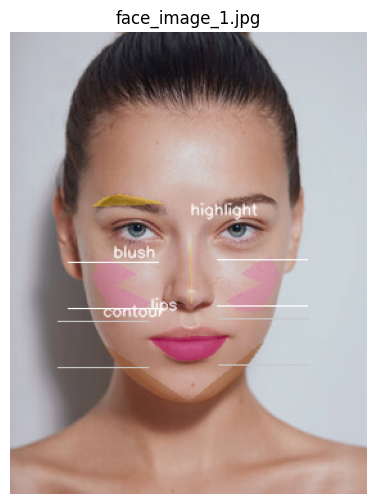

Saved: /content/output_face_image_10.jpeg


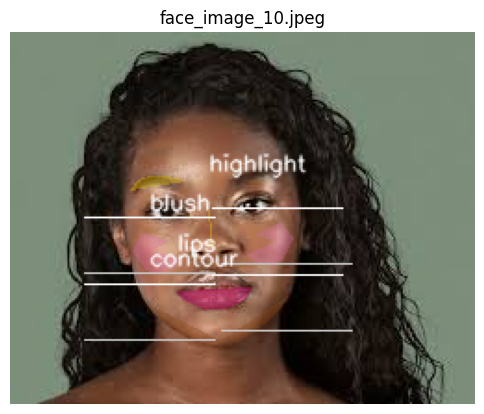

Saved: /content/output_face_image_11.png


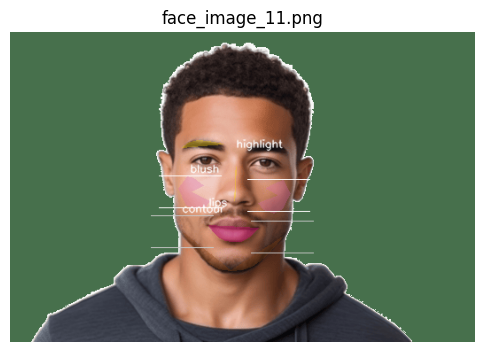

Saved: /content/output_face_image_12.png


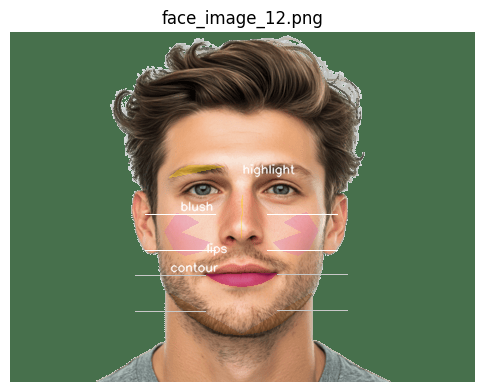

Saved: /content/output_face_image_13.jpeg


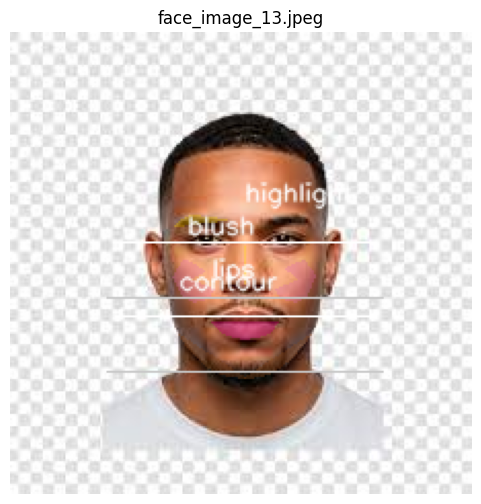

Saved: /content/output_face_image_14.png


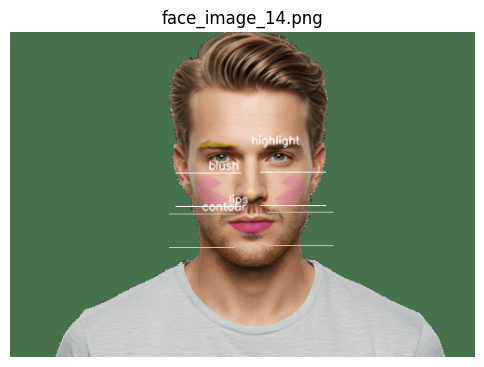

Saved: /content/output_face_image_15.jpg


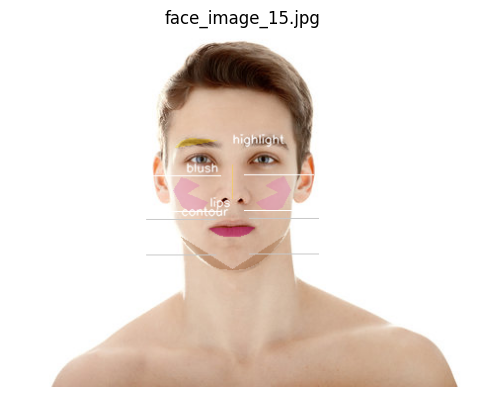

Saved: /content/output_face_image_2.jpg


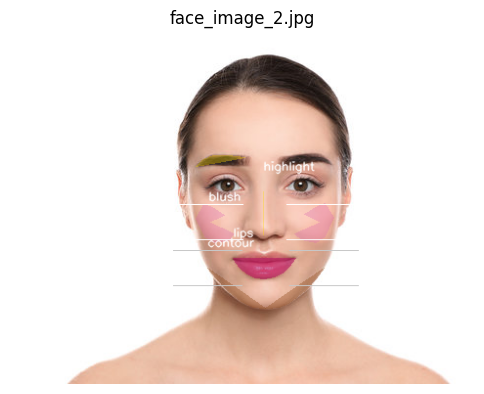

Saved: /content/output_face_image_3.jpeg


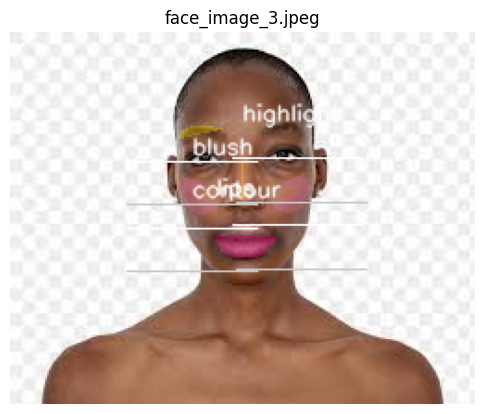

Saved: /content/output_face_image_4.jpeg


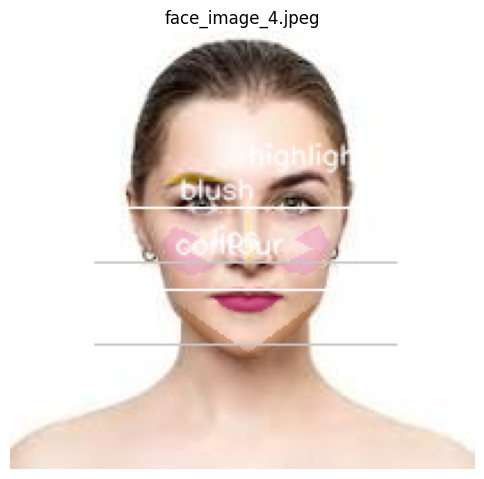

Saved: /content/output_face_image_5.png


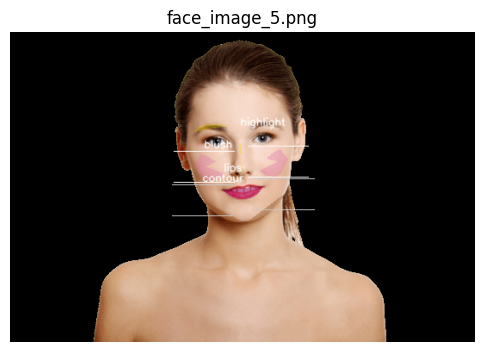

Saved: /content/output_face_image_6.png


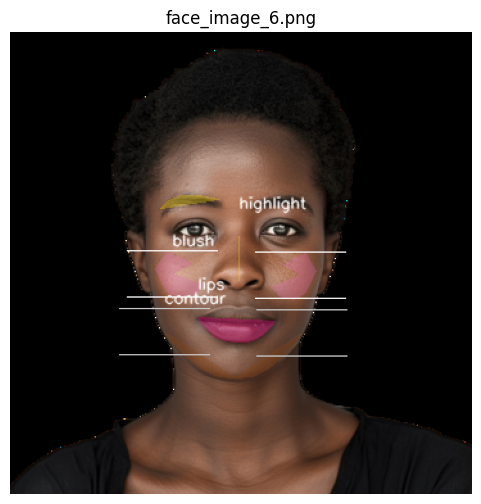

Saved: /content/output_face_image_7.png


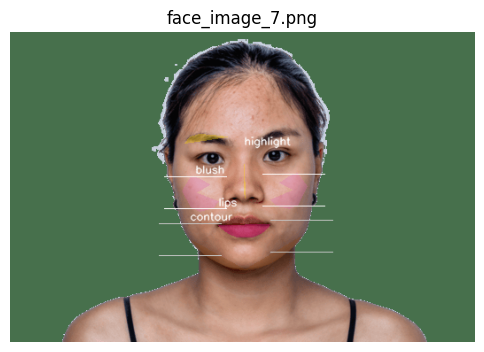

Saved: /content/output_face_image_8.jpg


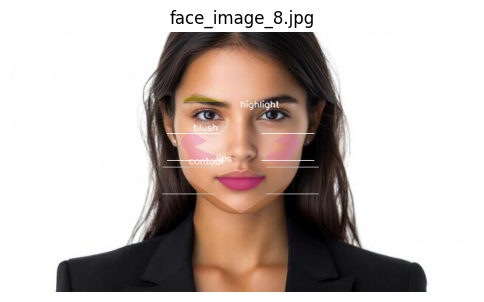

Saved: /content/output_face_image_9.jpg


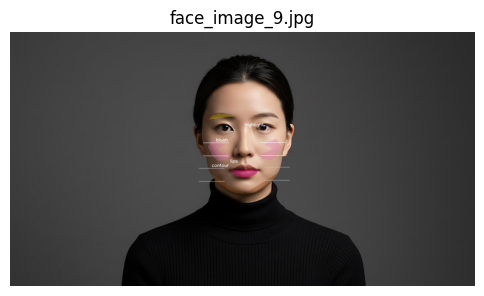

In [4]:
# ── Imports + setup ───────────────────────────────────────────────
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# ── Makeup zone definitions ───────────────────────────────────────
ZONES = {
    "blush_left":     [50, 101, 118, 117, 123, 187, 207, 206, 203],
    "blush_right":    [280, 330, 347, 346, 352, 411, 427, 426, 423],
    "contour_left":   [172, 136, 150, 149, 176, 148, 152],
    "contour_right":  [397, 365, 379, 378, 400, 377, 152],
    "highlight_nose": [6, 197, 195, 5, 4, 1],
    "highlight_brow": [70, 63, 105, 66, 107],
    "lip_outer":      [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291],
}

# BGR format — gold highlighter, dark pink lipstick
COLORS = {
    "blush_left":     (220, 105,180 , 80),   # soft pink BGR
    "blush_right":    (220, 105, 180, 80),
    "contour_left":   (139,   69, 19, 90),   # dark brown BGR
    "contour_right":  (139,   69, 19, 90),
    "highlight_nose": (255,   215, 0, 90),   # gold BGR
    "highlight_brow": (255,   215, 0, 90),   # gold BGR
    "lip_outer":      (180,  20, 100, 140) # dark pink BGR
}
LABELS = {
    "blush_left":     "blush",
    "contour_left":   "contour",
    "highlight_nose": "highlight",
    "lip_outer":      "lips"
}

# ── Drawing function ──────────────────────────────────────────────
def draw_makeup_zones(image, face_landmarks, h, w):
    for zone_name, indices in ZONES.items():
        points = []
        for idx in indices:
            lm = face_landmarks[idx]
            points.append((int(lm.x * w), int(lm.y * h)))
        pts = np.array(points, dtype=np.int32)

        r, g, b, alpha = COLORS[zone_name]
        overlay = image.copy()
        cv2.fillPoly(overlay, [pts], (b, g, r))
        opacity = alpha / 255.0
        cv2.addWeighted(overlay, opacity, image, 1 - opacity, 0, image)

    # Guide lines above and below blush zones
    for zone_name in ["blush_left", "blush_right"]:
        indices = ZONES[zone_name]
        lm_center = face_landmarks[indices[0]]
        cx, cy = int(lm_center.x * w), int(lm_center.y * h)
        cv2.line(image, (cx - 35, cy - 18), (cx + 35, cy - 18), (255, 255, 255), 1)
        cv2.line(image, (cx - 35, cy + 18), (cx + 35, cy + 18), (255, 255, 255), 1)

    # Guide lines above and below contour zones
    for zone_name in ["contour_left", "contour_right"]:
        indices = ZONES[zone_name]
        lm_center = face_landmarks[indices[0]]
        cx, cy = int(lm_center.x * w), int(lm_center.y * h)
        cv2.line(image, (cx - 35, cy - 18), (cx + 35, cy - 18), (200, 200, 200), 1)
        cv2.line(image, (cx - 35, cy + 18), (cx + 35, cy + 18), (200, 200, 200), 1)

    # Zone labels
    for zone_name, label in LABELS.items():
        if zone_name not in ZONES:
            continue
        indices = ZONES[zone_name]
        lm = face_landmarks[indices[0]]
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.putText(image, label, (cx, cy - 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

    return image

# ── Run on all images ─────────────────────────────────────────────
options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='/content/face_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE
)

with FaceLandmarker.create_from_options(options) as landmarker:
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is None:
            print(f"Skipping (unreadable): {image_path}")
            continue

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
        result = landmarker.detect(mp_image)

        if result.face_landmarks:
            h, w, _ = image.shape
            annotated = draw_makeup_zones(image.copy(), result.face_landmarks[0], h, w)

            # Save output
            output_path = f"/content/output_{os.path.basename(image_path)}"
            cv2.imwrite(output_path, annotated)
            print(f"Saved: {output_path}")

            # Display
            plt.figure(figsize=(6, 6))
            plt.title(os.path.basename(image_path))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()
        else:
            print(f"No face detected: {os.path.basename(image_path)}")


📁 face_image_1.jpg
   Skin tone  : Medium  |  Avg RGB: (203, 168, 158)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


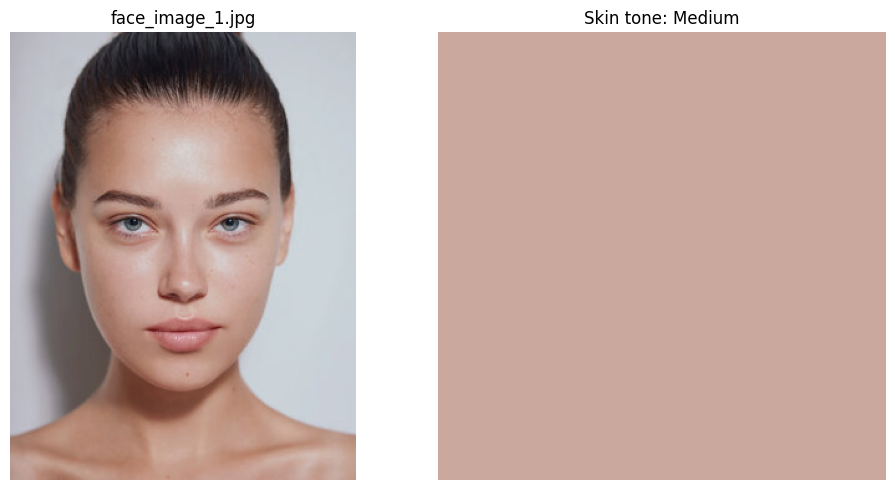


📁 face_image_10.jpeg
   Skin tone  : Light  |  Avg RGB: (193, 137, 107)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


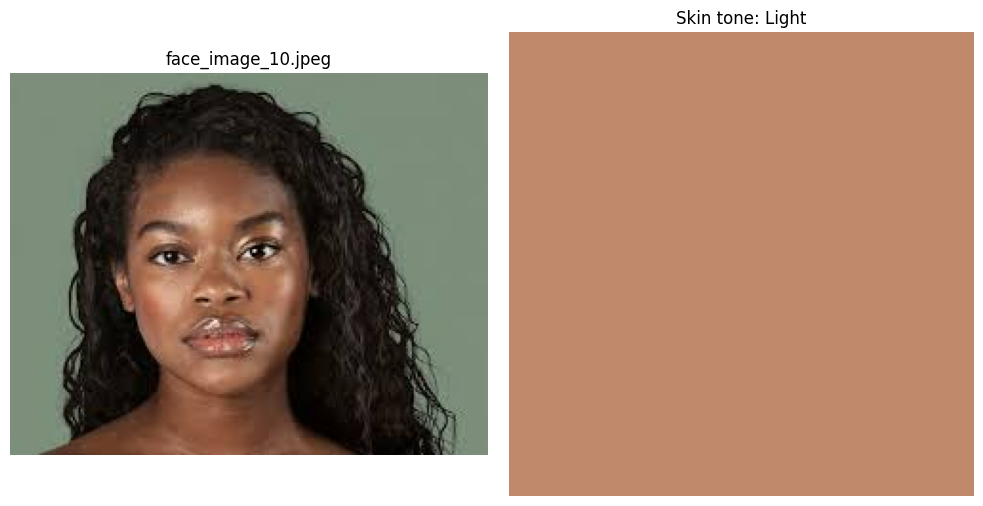


📁 face_image_11.png
   Skin tone  : Medium  |  Avg RGB: (214, 161, 139)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


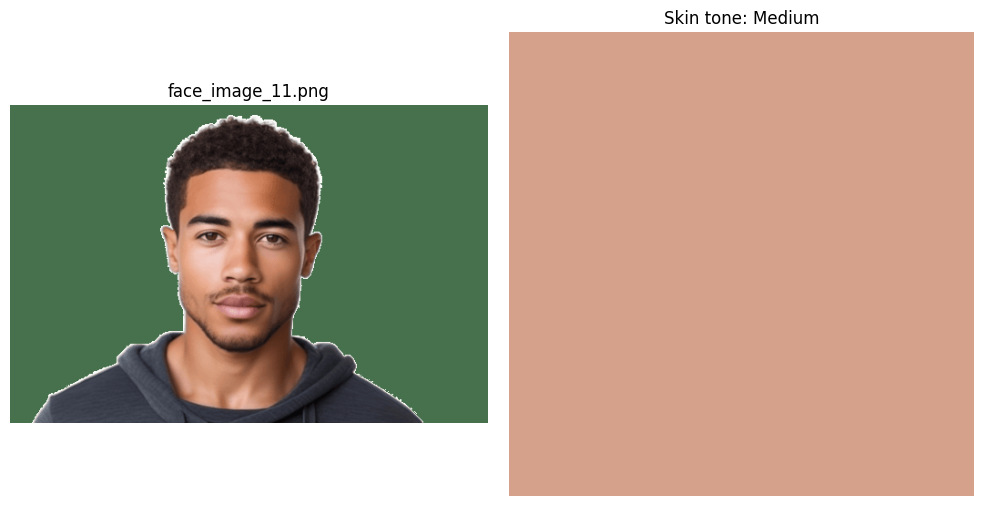


📁 face_image_12.png
   Skin tone  : Light  |  Avg RGB: (244, 193, 169)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


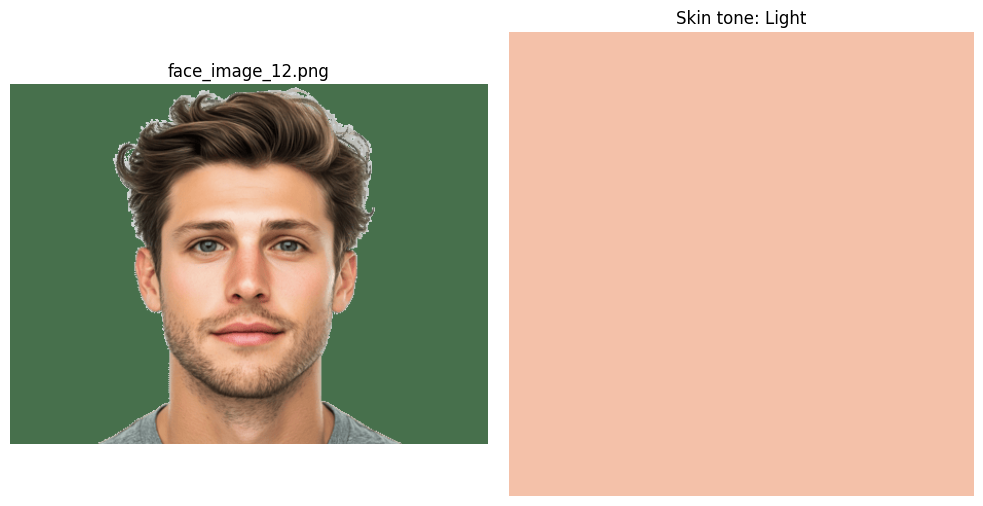


📁 face_image_13.jpeg
   Skin tone  : Light  |  Avg RGB: (233, 157, 114)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


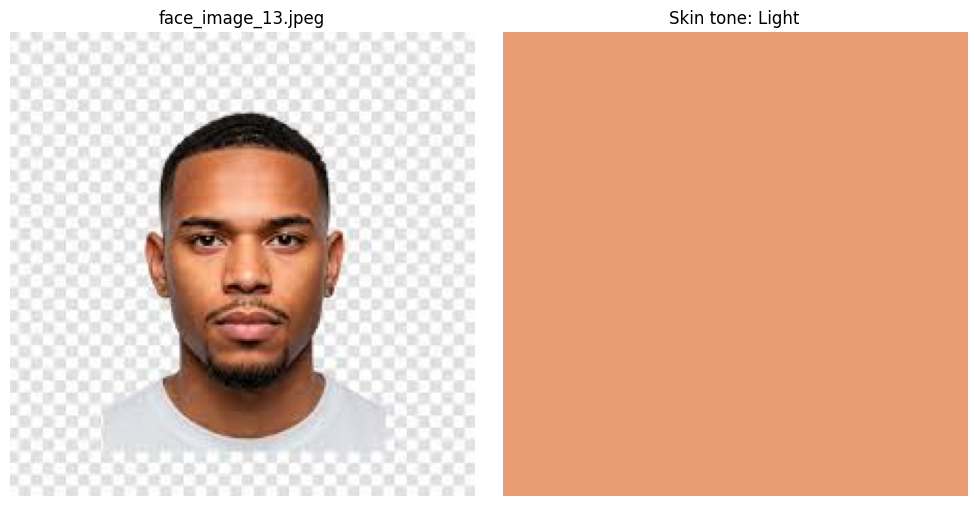


📁 face_image_14.png
   Skin tone  : Light  |  Avg RGB: (217, 172, 145)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


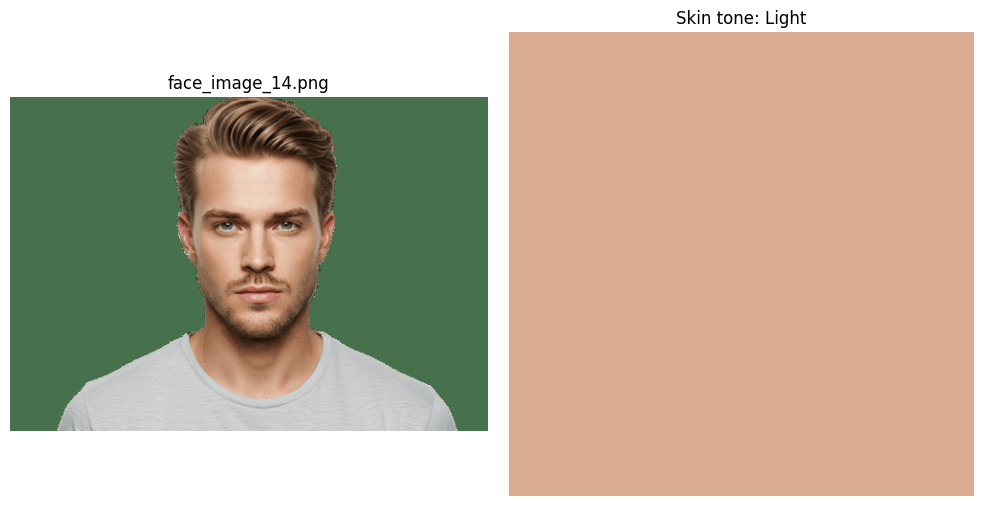


📁 face_image_15.jpg
   Skin tone  : Medium  |  Avg RGB: (227, 194, 174)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


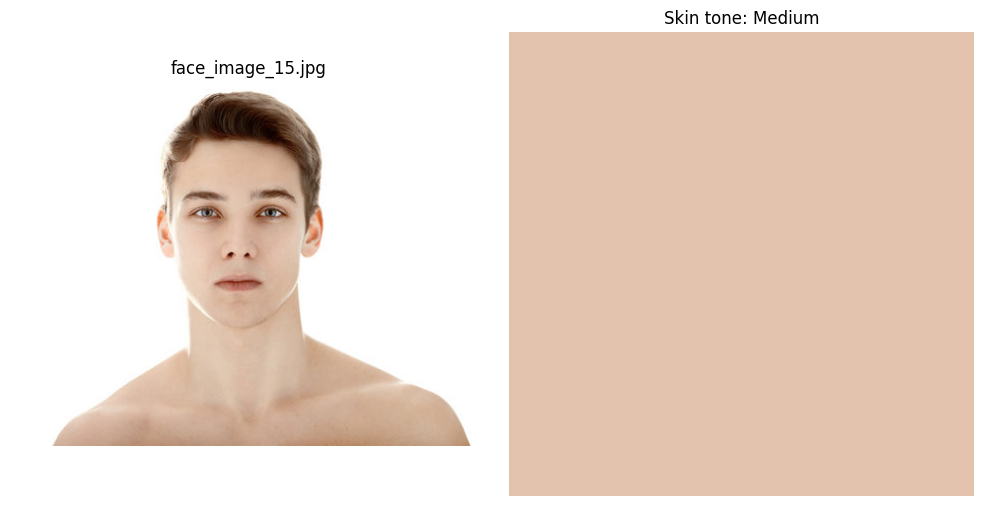


📁 face_image_2.jpg
   Skin tone  : Light  |  Avg RGB: (247, 195, 177)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


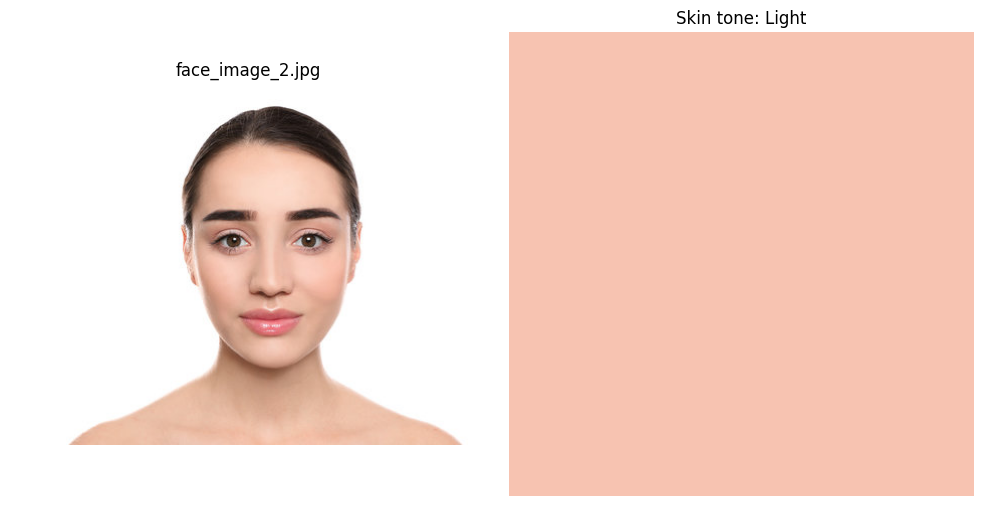


📁 face_image_3.jpeg
   Skin tone  : Medium  |  Avg RGB: (158, 101, 76)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


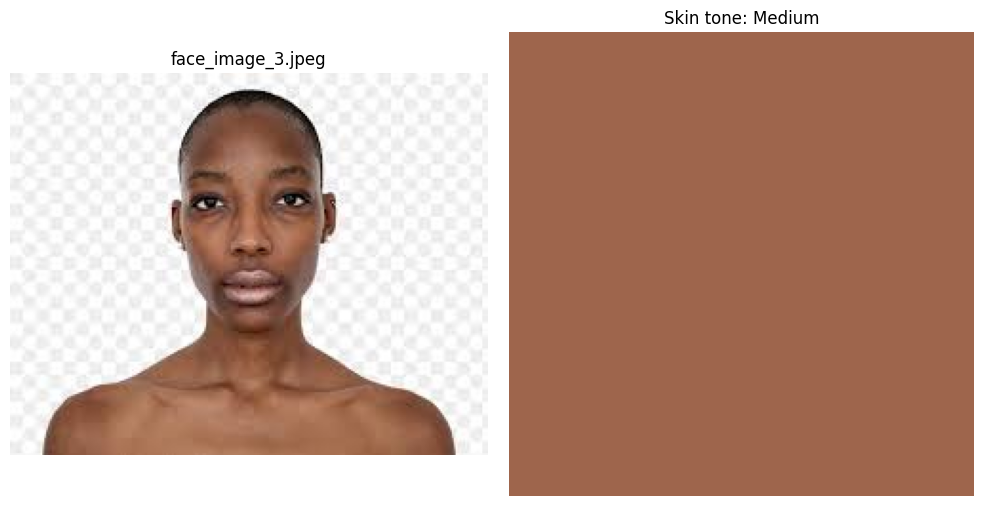


📁 face_image_4.jpeg
   Skin tone  : Medium  |  Avg RGB: (248, 221, 209)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


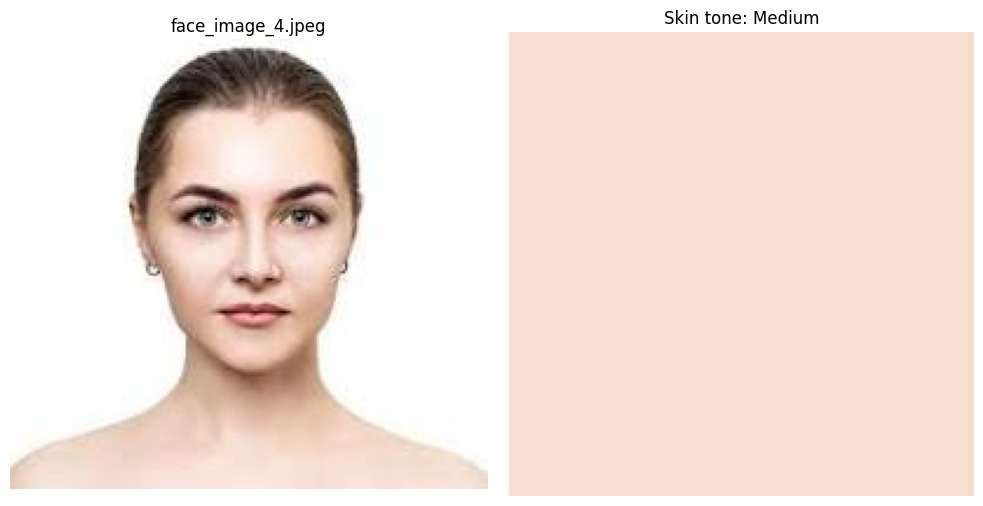


📁 face_image_5.png
   Skin tone  : Light  |  Avg RGB: (237, 199, 178)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


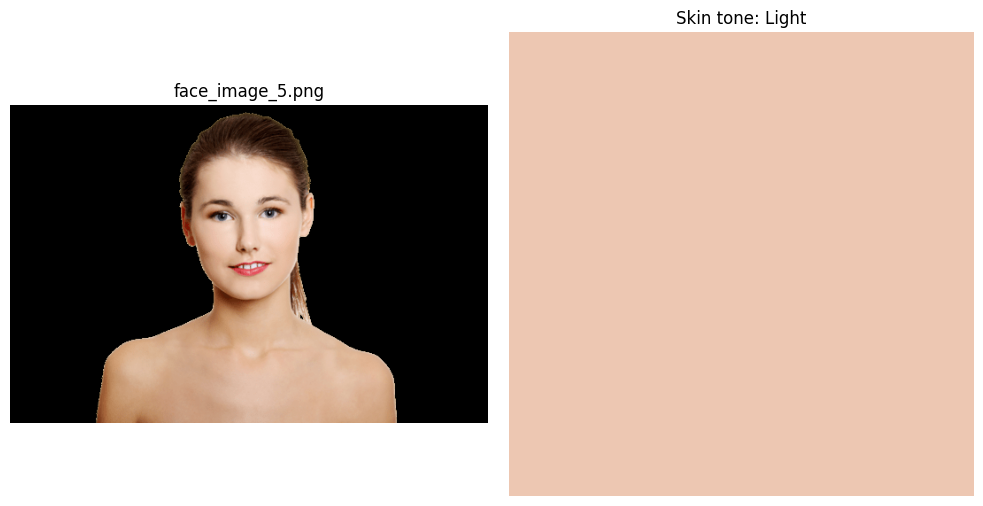


📁 face_image_6.png
   Skin tone  : Medium  |  Avg RGB: (183, 130, 104)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


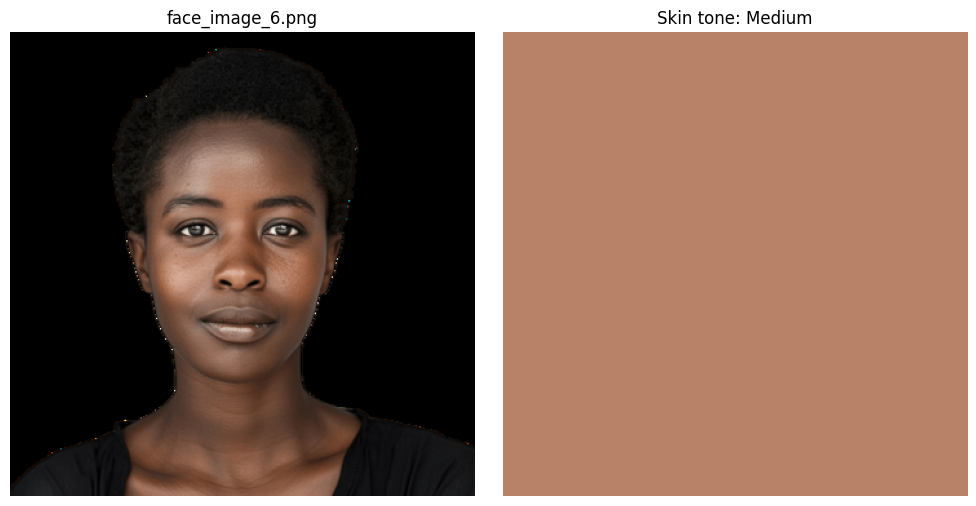


📁 face_image_7.png
   Skin tone  : Medium  |  Avg RGB: (222, 175, 161)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


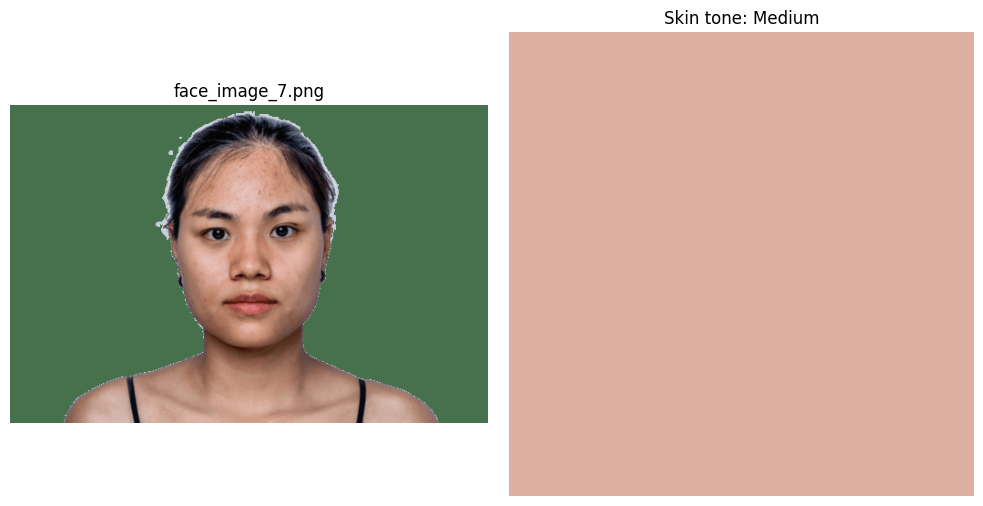


📁 face_image_8.jpg
   Skin tone  : Light  |  Avg RGB: (228, 179, 159)
   Foundation : Nude beige / Sand
   Blush      : Soft coral / Pink
   Contour    : Warm brown / Mushroom
   Lipstick   : Mauve / Berry
   Eyeshadow  : Bronze / Taupe
   Highlighter: Gold / Rose gold


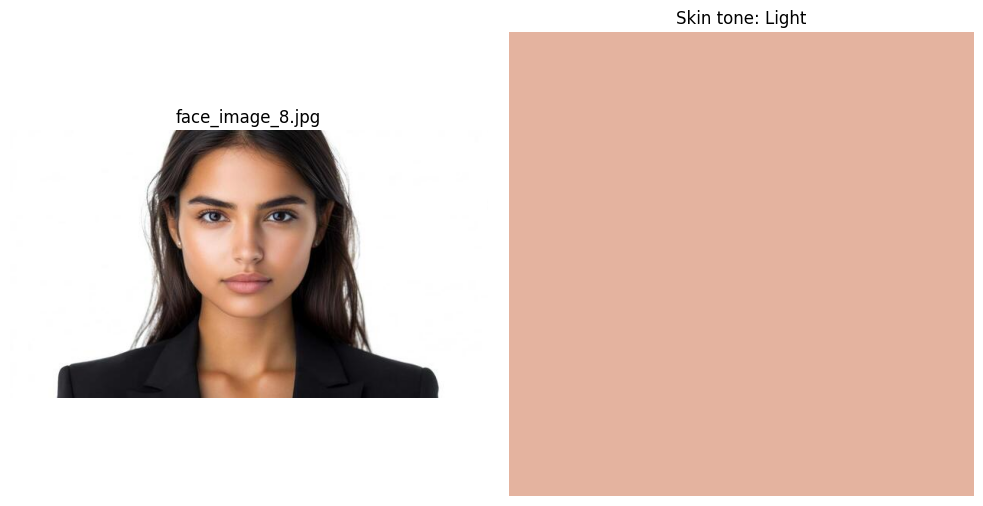


📁 face_image_9.jpg
   Skin tone  : Medium  |  Avg RGB: (208, 170, 149)
   Foundation : Golden beige / Honey
   Blush      : Coral / Terracotta
   Contour    : Warm chestnut / Caramel
   Lipstick   : Brick red / Nude brown
   Eyeshadow  : Copper / Warm gold
   Highlighter: Warm gold / Peach gold


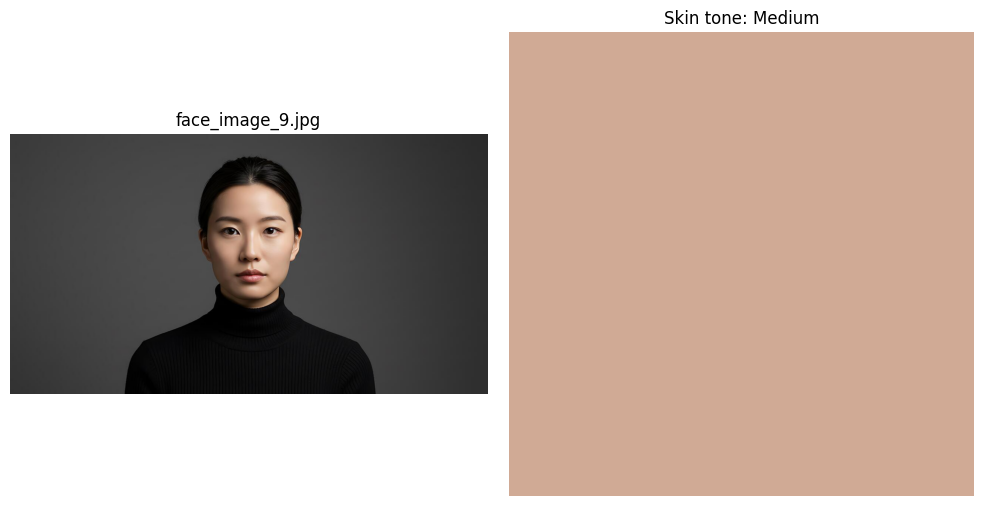

In [6]:
# ── Skin tone detection ───────────────────────────────────────────

# Cheek landmark indices for sampling skin colour
LEFT_CHEEK_IDX  = [50, 101, 118]
RIGHT_CHEEK_IDX = [280, 330, 347]

def get_skin_tone(image, face_landmarks, h, w):
    pixels = []

    for idx in LEFT_CHEEK_IDX + RIGHT_CHEEK_IDX:
        lm = face_landmarks[idx]
        x, y = int(lm.x * w), int(lm.y * h)
        patch = image[max(0,y-2):y+3, max(0,x-2):x+3]
        if patch.size > 0:
            pixels.append(patch.reshape(-1, 3))

    all_pixels = np.vstack(pixels)
    avg_rgb = np.mean(all_pixels, axis=0)  # already RGB, no flip needed

    r, g, b = avg_rgb

    L = 0.2126 * r + 0.7152 * g + 0.0722 * b
    ita = (np.arctan((L - 50) / (b + 0.001))) * (180 / np.pi)

    if ita > 55:
        tone = "Fair"
    elif ita > 41:
        tone = "Light"
    elif ita > 28:
        tone = "Medium"
    elif ita > 10:
        tone = "Tan"
    elif ita > -30:
        tone = "Deep"
    else:
        tone = "Rich"

    return tone, tuple(map(int, avg_rgb))

# Shade recommendations per skin tone
SHADE_GUIDE = {
    "Fair": {
        "foundation": "Ivory / Porcelain",
        "blush":      "Baby pink / Peach",
        "contour":    "Taupe / Cool brown",
        "lipstick":   "Nude pink / Rose",
        "eyeshadow":  "Champagne / Soft brown",
        "highlighter":"Pearl / Silver",
    },
    "Light": {
        "foundation": "Nude beige / Sand",
        "blush":      "Soft coral / Pink",
        "contour":    "Warm brown / Mushroom",
        "lipstick":   "Mauve / Berry",
        "eyeshadow":  "Bronze / Taupe",
        "highlighter":"Gold / Rose gold",
    },
    "Medium": {
        "foundation": "Golden beige / Honey",
        "blush":      "Coral / Terracotta",
        "contour":    "Warm chestnut / Caramel",
        "lipstick":   "Brick red / Nude brown",
        "eyeshadow":  "Copper / Warm gold",
        "highlighter":"Warm gold / Peach gold",
    },
    "Tan": {
        "foundation": "Caramel / Warm tan",
        "blush":      "Deep coral / Brick",
        "contour":    "Dark brown / Mocha",
        "lipstick":   "Burnt orange / Deep nude",
        "eyeshadow":  "Deep bronze / Rust",
        "highlighter":"Copper / Deep gold",
    },
    "Deep": {
        "foundation": "Espresso / Mahogany",
        "blush":      "Deep berry / Wine",
        "contour":    "Dark espresso / Ebony",
        "lipstick":   "Deep plum / Chocolate",
        "eyeshadow":  "Deep purple / Navy",
        "highlighter":"Rich gold / Bronze",
    },
    "Rich": {
        "foundation": "Ebony / Deep cocoa",
        "blush":      "Deep wine / Magenta",
        "contour":    "Black brown / Deepest brown",
        "lipstick":   "Burgundy / Deep wine",
        "eyeshadow":  "Jewel tones / Deep gold",
        "highlighter":"Deep bronze / Gunmetal",
    },
}

# ── Run detection + display shade guide ──────────────────────────
options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='/content/face_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE
)

with FaceLandmarker.create_from_options(options) as landmarker:
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is None:
            continue

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
        result = landmarker.detect(mp_image)

        if result.face_landmarks:
            h, w, _ = image.shape
            tone, avg_rgb = get_skin_tone(rgb_image, result.face_landmarks[0], h, w)
            shades = SHADE_GUIDE[tone]

            print(f"\n📁 {os.path.basename(image_path)}")
            print(f"   Skin tone  : {tone}  |  Avg RGB: {avg_rgb}")
            print(f"   Foundation : {shades['foundation']}")
            print(f"   Blush      : {shades['blush']}")
            print(f"   Contour    : {shades['contour']}")
            print(f"   Lipstick   : {shades['lipstick']}")
            print(f"   Eyeshadow  : {shades['eyeshadow']}")
            print(f"   Highlighter: {shades['highlighter']}")

            # Show face with skin tone swatch
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(rgb_image)
            axes[0].set_title(os.path.basename(image_path))
            axes[0].axis('off')

            # Draw colour swatch
            swatch = np.zeros((200, 200, 3), dtype=np.uint8)
            swatch[:] = avg_rgb
            axes[1].imshow(swatch)
            axes[1].set_title(f"Skin tone: {tone}")
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()
        else:
            print(f"No face detected: {os.path.basename(image_path)}")